# Лабораторная работа №1
## Анализ датасета Global Book ISBNDB

## 1. Текстовое описание выбранного набора данных

### Global Book ISBNDB Cleaned & Ready for Analysis

**Описание датасета:**

Данный датасет содержит очищенные метаданные о книгах из базы данных ISBNdb. Он включает в себя информацию о книгах со всего мира: ISBN-коды, названия, авторов, издательства, даты публикации, страны, языки и другие характеристики.

**Источник данных:** ISBNdb Metadata with Authors, Publishers, Countries, and Genres for Analysis

**Структура данных:**
- ISBN13 - 13-значный международный стандартный номер книги
- Book_Title - Название книги
- Author_Name - Имя автора
- Publisher_House - Издательство
- Publication_Date - Дата публикации
- Page_Count - Количество страниц
- Language - Язык издания
- Country - Страна издания
- Average_Rating - Средний рейтинг книги
- Review_Volume - Количество отзывов
- Is_Bestseller - Является ли книга бестселлером
- Record_Status - Статус записи

In [40]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка визуализации
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

print("Библиотеки импортированы!")

Библиотеки импортированы!


In [41]:
# Загрузка данных
df = pd.read_csv('isbndb_refined_kaggle.csv')
df['Is_Bestseller'] = df['Is_Bestseller'].astype(bool)
df['Publication_Date'] = pd.to_datetime(df['Publication_Date'], errors='coerce')
df['Publication_Year'] = df['Publication_Date'].dt.year

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

Размер датасета: 1000 строк, 13 столбцов


## 2. Основные характеристики датасета

In [42]:
# Первые строки датасета
df.head()

,ISBN13,Book_Title,Author_Name,Publisher_House,Publication_Date,Page_Count,Language,Country,Average_Rating,Review_Volume,Is_Bestseller,Record_Status,Publication_Year
0,9789697354961,Where the Crawdads Sing,Delia Owens,Simon & Schuster,2015-02-17,328.0,es,UK,3.71,4467,False,Refined,2015
1,9781402418010,The Midnight Library,Matt Haig,HarperCollins,2003-06-13,716.0,en,Pakistan,1.80,4464,False,Refined,2003
2,9784460967357,1984,George Orwell,Macmillan Publishers,2010-11-08,384.0,es,Australia,4.83,2757,False,Refined,2010
3,9788934927891,The Catcher in the Rye,J.D. Salinger,Hachette Book Group,2014-04-02,926.0,en,India,3.14,3100,False,Refined,2014
4,9781298737106,Foundation,Isaac Asimov,HarperCollins,2013-02-18,181.0,es,UK,2.52,3714,False,Refined,2013


In [43]:
# Общая информация
print(f"Количество записей: {df.shape[0]}")
print(f"Количество признаков: {df.shape[1]}")
print(f"\nПропущенных значений: {df.isnull().sum().sum()}")
print(f"\nУникальных авторов: {df['Author_Name'].nunique()}")
print(f"Уникальных стран: {df['Country'].nunique()}")
print(f"Уникальных языков: {df['Language'].nunique()}")

Количество записей: 1000
Количество признаков: 13

Пропущенных значений: 0

Уникальных авторов: 20
Уникальных стран: 10
Уникальных языков: 5


In [44]:
# Статистическое описание числовых признаков
df[['Page_Count', 'Average_Rating', 'Review_Volume']].describe()

,Page_Count,Average_Rating,Review_Volume
count,1000.000000,1000.000000,1000.000000
mean,545.127000,2.972910,2566.675000
std,255.991167,1.171084,1433.605632
min,100.000000,1.000000,1.000000
25%,320.750000,1.927500,1292.750000
50%,543.500000,2.915000,2663.500000
75%,762.250000,3.990000,3782.000000
max,1000.000000,5.000000,4995.000000


## 3. Визуальное исследование датасета

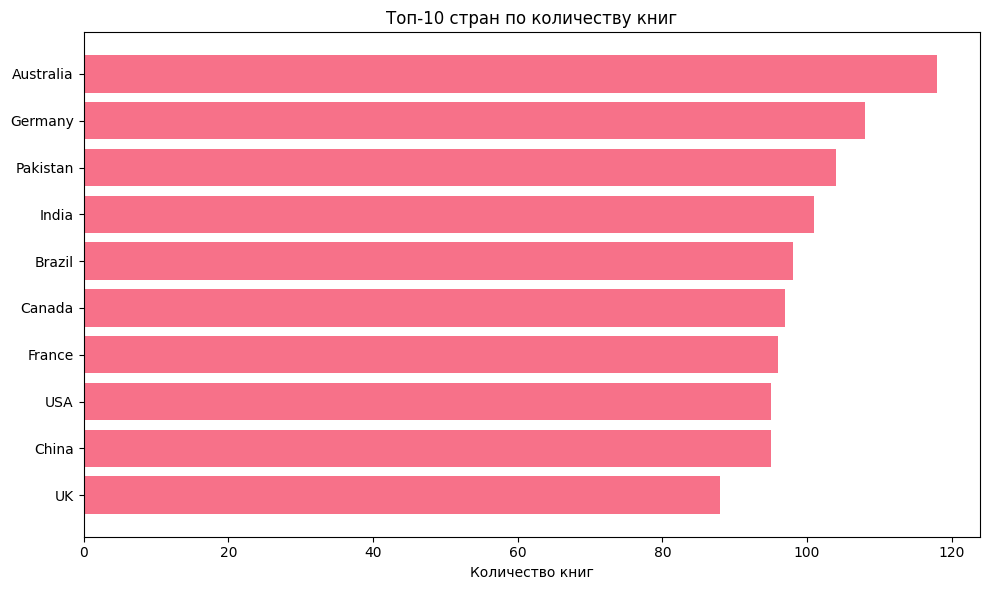

In [45]:
# Распределение книг по странам (топ-10)
plt.figure(figsize=(10, 6))
country_counts = df['Country'].value_counts().head(10)
plt.barh(country_counts.index, country_counts.values)
plt.xlabel('Количество книг')
plt.title('Топ-10 стран по количеству книг')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

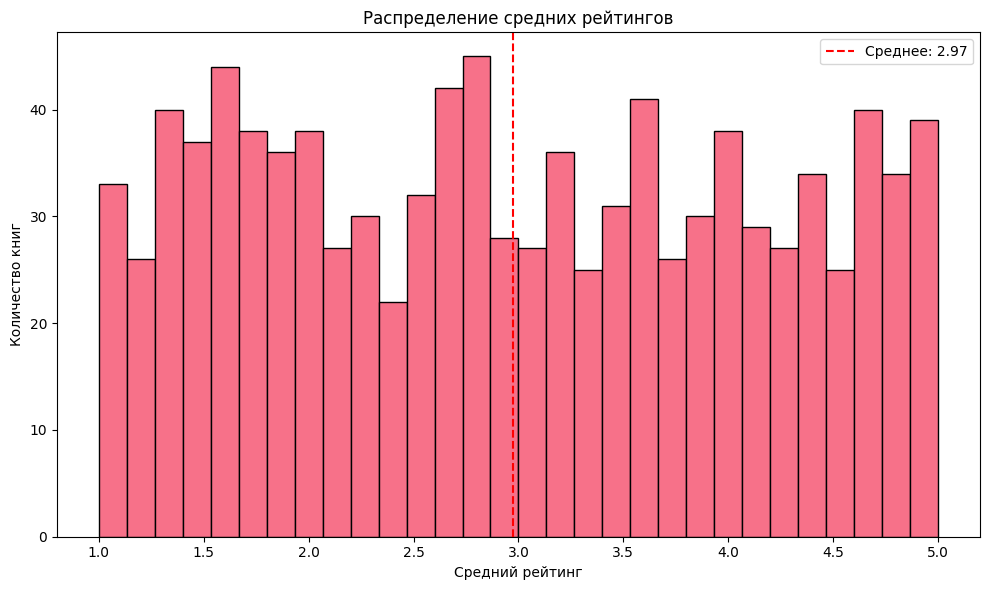

In [46]:
# Распределение рейтингов
plt.figure(figsize=(10, 6))
plt.hist(df['Average_Rating'].dropna(), bins=30, edgecolor='black')
plt.xlabel('Средний рейтинг')
plt.ylabel('Количество книг')
plt.title('Распределение средних рейтингов')
plt.axvline(df['Average_Rating'].mean(), color='red', linestyle='--', 
            label=f'Среднее: {df["Average_Rating"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

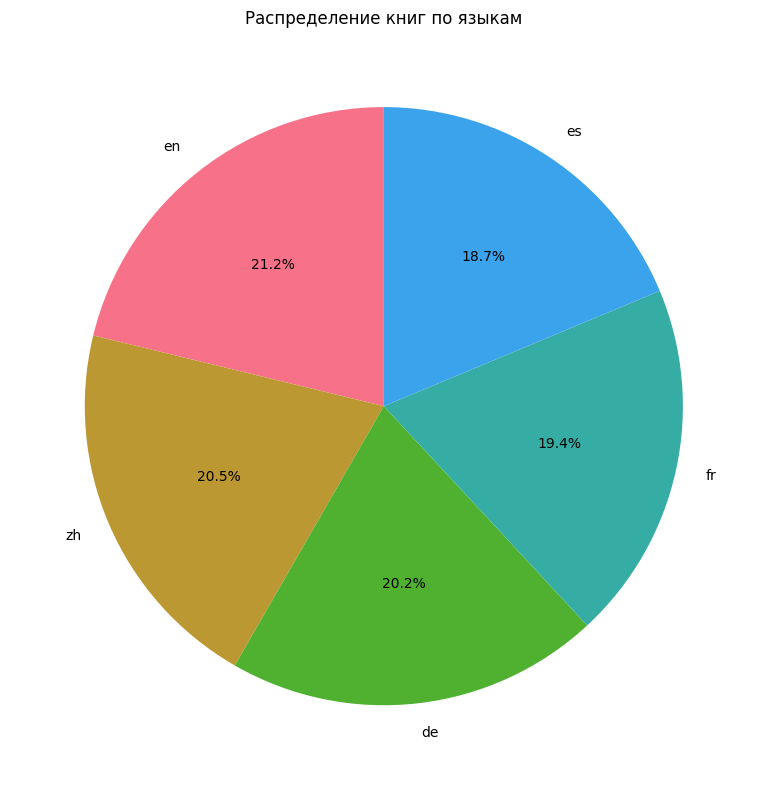

In [47]:
# Распределение книг по языкам
plt.figure(figsize=(8, 8))
language_counts = df['Language'].value_counts()
plt.pie(language_counts.values, labels=language_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Распределение книг по языкам')
plt.tight_layout()
plt.show()

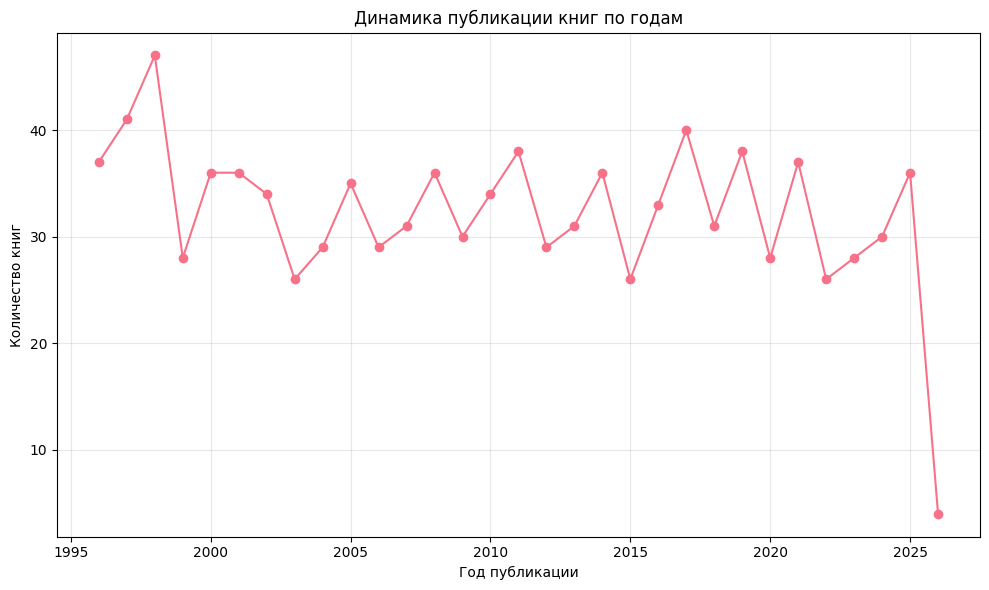

In [48]:
# Динамика публикаций по годам
plt.figure(figsize=(10, 6))
year_counts = df['Publication_Year'].value_counts().sort_index()
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.xlabel('Год публикации')
plt.ylabel('Количество книг')
plt.title('Динамика публикации книг по годам')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

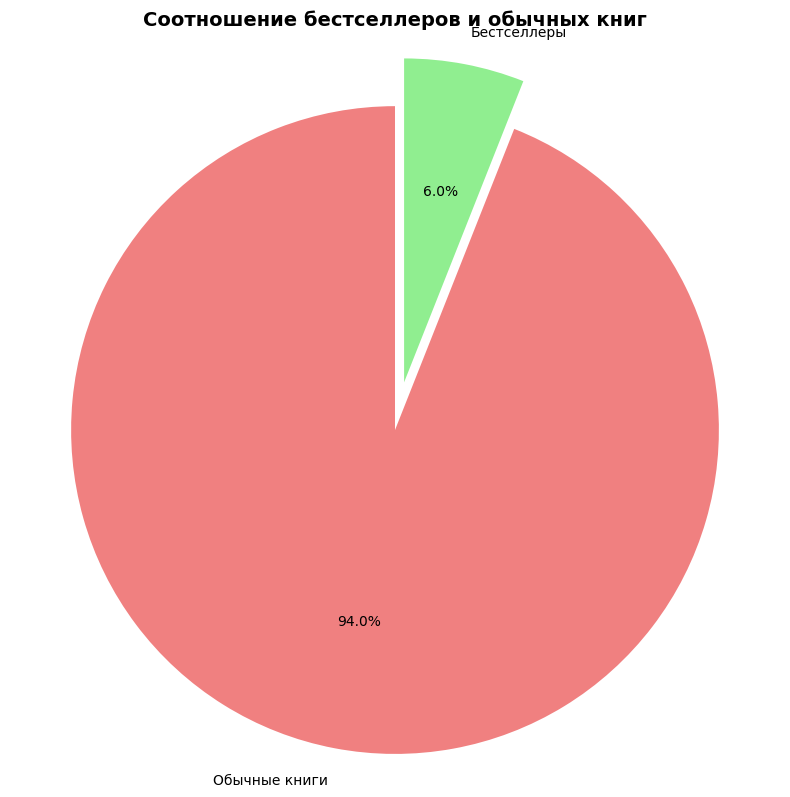

Количество бестселлеров: 60
Количество обычных книг: 940
Процент бестселлеров: 6.00%


In [52]:
# Распределение бестселлеров
plt.figure(figsize=(8, 8))
bestseller_counts = df['Is_Bestseller'].value_counts()
labels = ['Обычные книги', 'Бестселлеры']
colors = ['lightcoral', 'lightgreen']
explode = (0.05, 0.1)  # Выделяем бестселлеры

plt.pie(bestseller_counts.values, labels=labels, autopct='%1.1f%%', 
        startangle=90, colors=colors, explode=explode)
plt.title('Соотношение бестселлеров и обычных книг', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Вывод статистики
print(f"Количество бестселлеров: {df['Is_Bestseller'].sum()}")
print(f"Количество обычных книг: {(~df['Is_Bestseller']).sum()}")
print(f"Процент бестселлеров: {(df['Is_Bestseller'].sum() / len(df)) * 100:.2f}%")

## 4. Информация о корреляции признаков

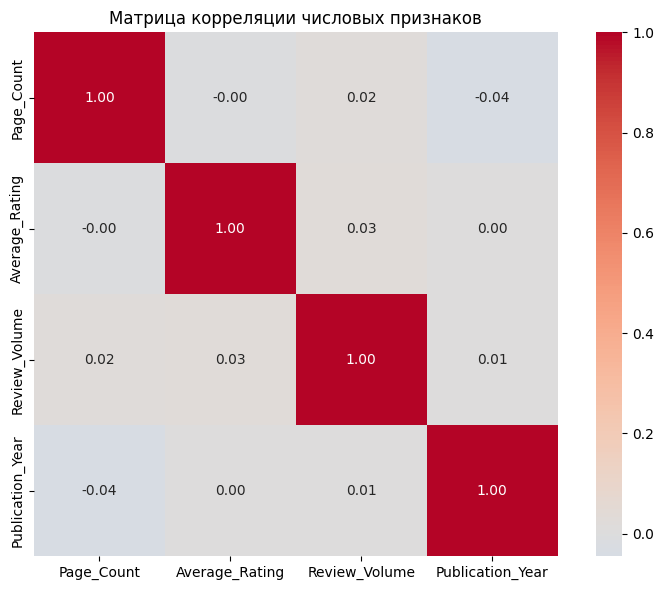

In [49]:
# Матрица корреляции
numeric_cols = ['Page_Count', 'Average_Rating', 'Review_Volume', 'Publication_Year']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Матрица корреляции числовых признаков')
plt.tight_layout()
plt.show()

In [50]:
# Вывод коэффициентов корреляции
print("Коэффициенты корреляции:")
print(correlation_matrix)

# Поиск значимых корреляций
print("\nЗаметные корреляции (|r| > 0.3):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.3:
            print(f"{correlation_matrix.columns[i]} ↔ {correlation_matrix.columns[j]}: {corr_value:.3f}")

Коэффициенты корреляции:
                  Page_Count  Average_Rating  Review_Volume  Publication_Year
Page_Count          1.000000       -0.003995       0.017114         -0.044772
Average_Rating     -0.003995        1.000000       0.032728          0.002891
Review_Volume       0.017114        0.032728       1.000000          0.005464
Publication_Year   -0.044772        0.002891       0.005464          1.000000

Заметные корреляции (|r| > 0.3):


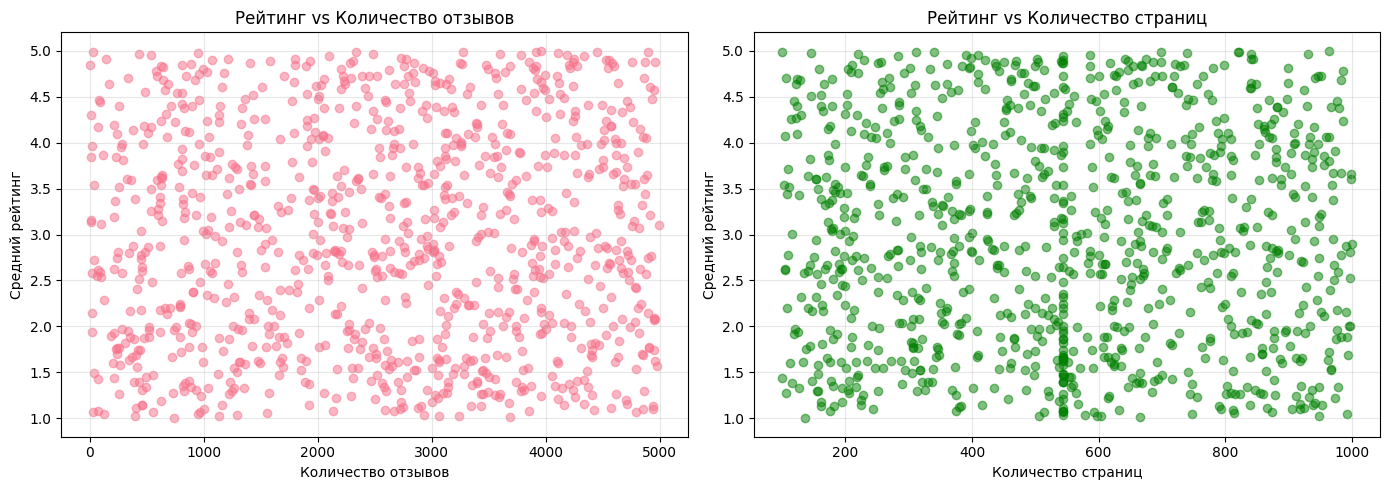

In [51]:
# Визуализация парных зависимостей
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Рейтинг vs Количество отзывов
axes[0].scatter(df['Review_Volume'], df['Average_Rating'], alpha=0.5)
axes[0].set_xlabel('Количество отзывов')
axes[0].set_ylabel('Средний рейтинг')
axes[0].set_title('Рейтинг vs Количество отзывов')
axes[0].grid(True, alpha=0.3)

# Количество страниц vs Рейтинг
axes[1].scatter(df['Page_Count'], df['Average_Rating'], alpha=0.5, color='green')
axes[1].set_xlabel('Количество страниц')
axes[1].set_ylabel('Средний рейтинг')
axes[1].set_title('Рейтинг vs Количество страниц')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()